# Customer Churn Analysis using SQL & Python

## Project Introduction

Customer churn is one of the most important business metrics, as retaining existing customers is often more cost-effective than acquiring new ones. This project performs an end-to-end customer churn analysis using a synthetic SQLite database containing customer, subscription, and support information.

The project demonstrates a complete data analysis workflow, including data cleaning, feature engineering, exploratory data analysis (EDA), SQL analysis, data visualization, and business insights. The objective is to identify customer behavior patterns, understand churn trends, and generate insights that can support better business decisions.

### Project Objectives

- Clean and preprocess raw customer data.
- Perform feature engineering to create useful analytical features.
- Analyze customer demographics and subscription patterns.
- Identify churn trends and customer lifetime value (CLTV).
- Answer business questions using SQL.
- Visualize key metrics and summarize business insights.

### Tools & Technologies

- Python
- SQLite
- SQL
- sqlite3
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

# 1. Import Libraries

In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# 2. Import Database / data

In [141]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """ 
             SELECT name
             FROM sqlite_master
             WHERE type = 'table';
            """

tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f'SELECT * FROM {table_name}', conn)
    globals()[f'df_{table_name}'] = df
    print(f'Created Dataframe: df_{table_name}')

conn.close()

Created Dataframe: df_db_customer
Created Dataframe: df_db_subscription
Created Dataframe: df_db_support


In [142]:
# Print tables names and column names 
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")

    # Get Column Information
    columns_query = f"PRAGMA table_info({table_name})"
    columns = pd.read_sql(columns_query, conn)

    print("Columns: ")
    print(columns['name'].to_list())

conn.close()    


Table Name: db_customer
Columns: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# 3. Data Cleaning

# Table1: db_customer

In [143]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,1,Chetan Pandey,India,Kerala,Prefer not to say,1999-07-31,"Fitness,Technology",502483
1,2,Lata Thakur,India,Punjab,Prefer not to say,1968-09-23,"Sports,Technology",R8VNRP
2,3,Kiran Gupta,India,Goa,Female,1966-06-24,Business,410260
3,4,Akash Bhatia,India,Tripura,Female,1967-03-11,Travel,111274
4,5,None,India,Karnataka,Female,1997-08-25,"Business,Cooking",131103


In [144]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  1500 non-null   int64 
 1   name        1445 non-null   object
 2   country     1500 non-null   object
 3   state       1305 non-null   object
 4   gender      1456 non-null   object
 5   dob         1455 non-null   object
 6   interests   1453 non-null   object
 7   pincode     1443 non-null   object
dtypes: int64(1), object(7)
memory usage: 93.9+ KB


In [145]:
# Data Cleaning
# a. check duplicate rows 
# b. rename columns - name into customer_name
# c. drop columns - interests & pincode
# d. change datatype - dob
# e. data standardization - gender  
# f. Check missing values
# g. Verify cleaned dataset

In [146]:
# a. check duplicate rows 
df_db_customer.duplicated().sum()

np.int64(15)

In [147]:
# Remove duplicate rows
df_db_customer.drop_duplicates(inplace=True)

In [148]:
# b. rename columns - name into Customer_Name
df_db_customer.rename(columns = {'name' : 'Customer_Name'}, inplace = True)
df_db_customer.head()

,customerid,Customer_Name,country,state,gender,dob,interests,pincode
0,1,Chetan Pandey,India,Kerala,Prefer not to say,1999-07-31,"Fitness,Technology",502483
1,2,Lata Thakur,India,Punjab,Prefer not to say,1968-09-23,"Sports,Technology",R8VNRP
2,3,Kiran Gupta,India,Goa,Female,1966-06-24,Business,410260
3,4,Akash Bhatia,India,Tripura,Female,1967-03-11,Travel,111274
4,5,None,India,Karnataka,Female,1997-08-25,"Business,Cooking",131103


In [149]:
# c. drop columns - interests & pincode
df_db_customer.drop(columns = ['interests', 'pincode'], inplace = True)
df_db_customer.head()

,customerid,Customer_Name,country,state,gender,dob
0,1,Chetan Pandey,India,Kerala,Prefer not to say,1999-07-31
1,2,Lata Thakur,India,Punjab,Prefer not to say,1968-09-23
2,3,Kiran Gupta,India,Goa,Female,1966-06-24
3,4,Akash Bhatia,India,Tripura,Female,1967-03-11
4,5,None,India,Karnataka,Female,1997-08-25


In [150]:
# d. change datatype - dob (from obj to datetime)

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
df_db_customer['dob']

0      1999-07-31
1      1968-09-23
2      1966-06-24
3      1967-03-11
4      1997-08-25
          ...    
1480   1900-09-22
1481   2000-10-24
1482   1984-07-12
1483   1969-06-27
1484   1963-04-29
Name: dob, Length: 1485, dtype: datetime64[ns]

In [151]:
# e. data standardization - gender  

# Remove spaces and view unique gender values
df_db_customer['gender'] = df_db_customer['gender'].str.strip()

In [152]:
# Standardize gender values and replace invalid entries with NaN
df_db_customer['gender'] = df_db_customer['gender'].replace({
                                                            'female': 'Female',
                                                            'FEMALE': 'Female',
                                                            'F': 'Female',
                                                            'male': 'Male',
                                                            'MALE': 'Male',
                                                            'M' : 'Male',
                                                             None : np.nan,
                                                            'unknown' : np.nan,
                                                            'othr' : np.nan
                                                         })


In [153]:
# Verify cleaned gender values
df_db_customer['gender'].unique()

array(['Prefer not to say', 'Female', 'Other', 'Male', nan], dtype=object)

In [154]:
# f. Check missing values (%)
missing_percent = round(df_db_customer.isna().mean() * 100, 2)

for col, per in missing_percent.items():
    print(f"{col} = {per}%")

customerid = 0.0%
Customer_Name = 3.64%
country = 0.0%
state = 13.06%
gender = 5.19%
dob = 2.96%


In [155]:
# g. Verify cleaned dataset

In [156]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1485 entries, 0 to 1484
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     1485 non-null   int64         
 1   Customer_Name  1431 non-null   object        
 2   country        1485 non-null   object        
 3   state          1291 non-null   object        
 4   gender         1408 non-null   object        
 5   dob            1441 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 81.2+ KB


In [157]:
df_db_customer.head()

,customerid,Customer_Name,country,state,gender,dob
0,1,Chetan Pandey,India,Kerala,Prefer not to say,1999-07-31
1,2,Lata Thakur,India,Punjab,Prefer not to say,1968-09-23
2,3,Kiran Gupta,India,Goa,Female,1966-06-24
3,4,Akash Bhatia,India,Tripura,Female,1967-03-11
4,5,None,India,Karnataka,Female,1997-08-25


In [158]:
df_db_customer.sample(5)

,customerid,Customer_Name,country,state,gender,dob
353,354,KUNAL JAIN,India,Jharkhand,Male,1962-09-16
1094,1095,Parth Pandey,India,Madhya Pradesh,Female,1983-03-11
446,447,Ganesh Jadhav,India,Karnataka,Other,1970-01-06
150,151,om bose,India,Jharkhand,Prefer not to say,2000-10-30
710,711,Nisha Chopra,India,Odisha,Other,1960-02-06


# Table2: db_subscription

In [159]:
df_db_subscription.head(18)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,1,2025-05-15,Basic,2026-06-06,Student,Monthly,None,None,312.11,3997.47,25.0
1,2,2025-12-25,Standard,18-05-2026,Business,Monthly,None,None,652.76,4976.94,0.0
2,3,2021-02-08,Premium,2022-07-28,Family,Annual,None,None,1689.90,107210.60,4.0
3,4,2024-02-10,Premium,2025-03-22,Family,Annual,2026-06-28,Too Expensive,1980.20,74147.50,88.0
4,5,2020-05-31,Standard,2020-10-25,Student,Quarterly,2020-11-10,Moved,766.47,4752.77,84.0
5,6,2025-10-26,Standard,2026-12-14,Individual,Monthly,None,None,852.18,8177.42,7.0
6,7,2026-08-06,Free,2026-08-06,Student,Annual,2026-08-06,Payment Failure,0.00,0.00,66.0
7,8,2021-04-26,Free,2024-04-23,Family,Annual,06/20/2024,Personal Reasons,0.00,0.00,78.0
8,9,2025-02-09,Standard,2026-08-05,Business,Monthly,None,None,683.84,NaN,20.0
9,10,2020-07-03,Standard,2020-07-29,Business,Quarterly,2021-11-18,Moved,983.53,15107.63,74.0


In [160]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               1500 non-null   int64  
 1   subscription_start_date  1500 non-null   object 
 2   subscription_type        1450 non-null   object 
 3   renewal_date             1461 non-null   object 
 4   plan_type                1459 non-null   object 
 5   contract_type            1461 non-null   object 
 6   cancellation_date        452 non-null    object 
 7   cancellation_reason      452 non-null    object 
 8   monthly_charges          1459 non-null   float64
 9   cltv                     1446 non-null   float64
 10  churn_score              1455 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 129.0+ KB


In [161]:

# Data Cleaning - Table 2
# 1. Change datatype - subscription_start_date, renewal_date, cancellation_date
# 2. Check & Remove duplicate rows
# 3. Check missing values
# 4. Verify Categorical Column


In [162]:
# 1. Change datatype - subscription_start_date, renewal_date, cancellation_date
# Convert date columns to datetime format

df_db_subscription['subscription_start_date'] = pd.to_datetime(
    df_db_subscription['subscription_start_date'],
    format='mixed',
    errors='coerce'
)
df_db_subscription['renewal_date'] = pd.to_datetime(
    df_db_subscription['renewal_date'],
    format='mixed',
    errors='coerce'
)
df_db_subscription['cancellation_date'] = pd.to_datetime(
    df_db_subscription['cancellation_date'],
    format='mixed',
    errors='coerce'
)

In [163]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               1500 non-null   int64         
 1   subscription_start_date  1500 non-null   datetime64[ns]
 2   subscription_type        1450 non-null   object        
 3   renewal_date             1461 non-null   datetime64[ns]
 4   plan_type                1459 non-null   object        
 5   contract_type            1461 non-null   object        
 6   cancellation_date        452 non-null    datetime64[ns]
 7   cancellation_reason      452 non-null    object        
 8   monthly_charges          1459 non-null   float64       
 9   cltv                     1446 non-null   float64       
 10  churn_score              1455 non-null   float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(4)
memory usage: 129.0+ KB


In [164]:
# 2. check duplicate rows 

df_db_subscription.duplicated().sum()

np.int64(15)

In [165]:
# Remove duplicate rows
df_db_subscription.drop_duplicates(inplace=True)

In [166]:
df_db_subscription.duplicated().sum()

np.int64(0)

In [167]:
# 3. Check missing values

round(df_db_subscription.isna().mean() * 100, 2)

customerid                  0.00
subscription_start_date     0.00
subscription_type           3.37
renewal_date                2.56
plan_type                   2.69
contract_type               2.63
cancellation_date          69.70
cancellation_reason        69.70
monthly_charges             2.76
cltv                        3.64
churn_score                 3.03
dtype: float64

In [168]:
# Observation:
# High missing values in cancellation_date and cancellation_reason are expected,
# as active customers do not have cancellation details.

In [169]:
# Verify Categorical Column

In [170]:
# 1. Check unique subscription types
df_db_subscription['subscription_type'].unique()

array(['Basic', 'Standard', 'Premium', 'Free', None], dtype=object)

In [171]:
# 2. Check unique Plan Types
df_db_subscription['plan_type'].unique()

array(['Student', 'Business', 'Family', 'Individual', None], dtype=object)

In [172]:
# 3. Check unique Contract Types
df_db_subscription['contract_type'].unique()

array(['Monthly', 'Annual', 'Quarterly', None], dtype=object)

In [173]:
# 4. Check unique Cancellation Types
df_db_subscription['cancellation_reason'].unique()

array([None, 'Too Expensive', 'Moved', 'Payment Failure',
       'Personal Reasons', 'Switched Competitor', 'Not Using Service',
       'Poor Support', 'Lack of Features', 'Technical Issues'],
      dtype=object)

# Table 3: db_support

In [174]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,151,2025-06-22,0.0,5.0,N/A,Poor customer support
1,434,2026-08-22,4.0,5.0,Priority,App crashes frequently
2,1073,2024-10-08,2.0,1.0,Error,Auto renewal problem
3,882,2026-05-10,4.0,4.0,A101,Duplicate charge on card
4,408,2020-11-01,4.0,3.0,None,Payment failed


In [175]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerid      500 non-null    int64  
 1   complaint_date  500 non-null    object 
 2   escalations     481 non-null    float64
 3   csat_score      490 non-null    float64
 4   col_1           488 non-null    object 
 5   comment         477 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 23.6+ KB


In [176]:
# Data Cleaning - Table 3 (db_support)
# a. Check & remove Duplicates Column
# b. Change Datatype - complaint_date
# c. Standardize missing values in col_1
# d. Check missing values

In [177]:
# a. Check Duplicates Column
df_db_support.duplicated().sum()

np.int64(10)

In [178]:
# Remove duplicate rows
df_db_support.drop_duplicates(inplace=True)

In [179]:
# Again check duplicate col 
df_db_support.duplicated().sum()

np.int64(0)

In [180]:
# b. Change Datatype - complaint_date

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [181]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
Index: 490 entries, 0 to 489
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      490 non-null    int64         
 1   complaint_date  490 non-null    datetime64[ns]
 2   escalations     471 non-null    float64       
 3   csat_score      480 non-null    float64       
 4   col_1           480 non-null    object        
 5   comment         467 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 26.8+ KB


In [182]:
df_db_support['complaint_date'].dtypes

dtype('<M8[ns]')

In [183]:
df_db_support['col_1'].value_counts(dropna=False)

col_1
Low         49
NULL        47
Blank       44
A101        43
A303        42
            41
Medium      41
Priority    40
High        40
N/A         33
A202        32
Error       28
None        10
Name: count, dtype: int64

In [184]:
# c. Standardize missing values in col_1
df_db_support['col_1'] = df_db_support['col_1'].replace({
    'NULL': np.nan,
    'Blank': np.nan,
    'N/A': np.nan,
    'None': np.nan,
    '': np.nan,
    'Error': np.nan
})

In [185]:
df_db_support['col_1'].value_counts(dropna=False)

col_1
NaN         193
Low          49
A101         43
A303         42
Medium       41
Priority     40
High         40
A202         32
None         10
Name: count, dtype: int64

In [186]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
Index: 490 entries, 0 to 489
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      490 non-null    int64         
 1   complaint_date  490 non-null    datetime64[ns]
 2   escalations     471 non-null    float64       
 3   csat_score      480 non-null    float64       
 4   col_1           287 non-null    object        
 5   comment         467 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 26.8+ KB


In [187]:
df_db_support['col_1'].head(20)

0          NaN
1     Priority
2          NaN
3         A101
4         None
5     Priority
6         A202
7          NaN
8         A303
9         None
10         Low
11        A101
12         NaN
13         Low
14         NaN
15      Medium
16    Priority
17        A101
18      Medium
19        A202
Name: col_1, dtype: object

In [188]:
# d. Check missing values

In [189]:
# d.1 - Check escalation values
df_db_support['escalations'].value_counts(dropna=False)

escalations
0.0    86
5.0    80
2.0    78
3.0    77
1.0    76
4.0    74
NaN    19
Name: count, dtype: int64

In [190]:
# Observation:
# No invalid escalation values found.

In [191]:
# d.2 - Check CSAT score values
df_db_support['csat_score'].value_counts(dropna=False).sort_index()

csat_score
1.0    102
2.0     88
3.0     87
4.0     97
5.0    106
NaN     10
Name: count, dtype: int64

In [192]:
# Observation:
# CSAT scores are within the expected range (1–5).

In [193]:
# d.3 - Check unique support comments
df_db_support['comment'].unique()

array(['Poor customer support', 'App crashes frequently',
       'Auto renewal problem', 'Duplicate charge on card',
       'Payment failed', 'Password reset', 'Late response from support',
       'Account locked', 'Subscription not updated',
       'Unable to update profile', 'Unable to login', 'account locked',
       'Need invoice', 'Network issue', 'Feature request',
       'Cannot cancel plan', 'OTP not received', 'App not loading',
       'APP NOT LOADING', None, 'Wrong plan activated',
       'Unable to download invoice', 'Video buffering issue',
       'Email verification failed', 'App freezes', 'Slow application',
       'Data sync issue', ' Network issue ', ' Feature request ',
       ' Unable to download invoice ', 'ACCOUNT LOCKED',
       'late response from support', 'Refund delayed', 'unable to login',
       ' Password reset ', 'PASSWORD RESET', 'feature request',
       'NETWORK ISSUE', 'Billing issue', 'AUTO RENEWAL PROBLEM',
       'NEED INVOICE', ' Subscription not u

In [194]:
# Remove leading and trailing spaces
df_db_support['comment'] = df_db_support['comment'].str.strip()

In [195]:
# Standardize comment values
df_db_support['comment'] = df_db_support['comment'].str.title()

In [196]:
# Verify cleaned support comments
df_db_support['comment'].unique()

array(['Poor Customer Support', 'App Crashes Frequently',
       'Auto Renewal Problem', 'Duplicate Charge On Card',
       'Payment Failed', 'Password Reset', 'Late Response From Support',
       'Account Locked', 'Subscription Not Updated',
       'Unable To Update Profile', 'Unable To Login', 'Need Invoice',
       'Network Issue', 'Feature Request', 'Cannot Cancel Plan',
       'Otp Not Received', 'App Not Loading', None,
       'Wrong Plan Activated', 'Unable To Download Invoice',
       'Video Buffering Issue', 'Email Verification Failed',
       'App Freezes', 'Slow Application', 'Data Sync Issue',
       'Refund Delayed', 'Billing Issue'], dtype=object)

# 4. Feature Enginerring

In [197]:
# Create new col from existing col - Age

df_db_customer['Age'] = (pd.Timestamp.today().year - df_db_customer['dob'].dt.year)

In [198]:
# Create Subscription tenure (days)

df_db_subscription['Subscription_Tenure'] = (df_db_subscription['renewal_date'] - df_db_subscription['subscription_start_date']).dt.days

In [199]:
# create a new col using existing col - churn_flag

df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [200]:
# Create annual charges

df_db_subscription['Annual_Charges'] = (df_db_subscription['monthly_charges'] * 12)

In [201]:
# Create Complain Month

df_db_support['Complaint_Month'] = df_db_support['complaint_date'].dt.month_name()

In [202]:
# Create Complain Year

df_db_support['Complaint_Year'] = df_db_support['complaint_date'].dt.year

# 5. Merge Tables

In [203]:
# Merging df_db_subscription & df_db_support to -- df_db_customer
df_customer_churn = (df_db_customer
                            .merge(df_db_subscription, on = 'customerid', how = 'left')
                            .merge(df_db_support, on = 'customerid', how = 'left')
                     ) 

In [204]:
df_customer_churn.head()

,customerid,Customer_Name,country,state,gender,dob,Age,subscription_start_date,subscription_type,renewal_date,...,Subscription_Tenure,churn_flag,Annual_Charges,complaint_date,escalations,csat_score,col_1,comment,Complaint_Month,Complaint_Year
0,1,Chetan Pandey,India,Kerala,Prefer not to say,1999-07-31,27.0,2025-05-15,Basic,2026-06-06,...,387.0,0,3745.32,2025-09-12,5.0,1.0,NaN,Duplicate Charge On Card,September,2025.0
1,2,Lata Thakur,India,Punjab,Prefer not to say,1968-09-23,58.0,2025-12-25,Standard,2026-05-18,...,144.0,0,7833.12,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Kiran Gupta,India,Goa,Female,1966-06-24,60.0,2021-02-08,Premium,2022-07-28,...,535.0,0,20278.80,2022-03-17,2.0,3.0,NaN,Cannot Cancel Plan,March,2022.0
3,4,Akash Bhatia,India,Tripura,Female,1967-03-11,59.0,2024-02-10,Premium,2025-03-22,...,406.0,1,23762.40,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,5,None,India,Karnataka,Female,1997-08-25,29.0,2020-05-31,Standard,2020-10-25,...,147.0,1,9197.64,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [205]:
df_customer_churn['gender'].unique()

array(['Prefer not to say', 'Female', 'Other', 'Male', nan], dtype=object)

In [206]:
df_customer_churn.shape

(1525, 27)

In [207]:
df_db_subscription.shape

(1485, 14)

In [208]:
df_db_customer.shape

(1485, 7)

In [209]:
df_db_support.shape

(490, 8)

In [210]:
df_db_subscription['customerid'].nunique()

1485

In [211]:
df_db_customer['customerid'].nunique()

1485

In [212]:
df_db_support['customerid'].nunique()

450

In [213]:
df_db_support['complaint_count'] =  df_db_support.groupby('customerid')['customerid'].transform('count')

In [214]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep = 'last')

In [215]:
df_db_support['customerid'].size

450

In [216]:
df_customer_churn = (df_db_customer
                            .merge(df_db_subscription, on = 'customerid', how = 'left')
                            .merge(df_db_support, on = 'customerid', how = 'left')
                     ) 

In [217]:
df_customer_churn.shape

(1485, 28)

# 6. Exploratory Data Analysis (EDA)

# 6.1. Dataset Overview

In [218]:
# Dataset shape
df_customer_churn.shape

(1485, 28)

In [219]:
# Dataset information
df_customer_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1485 entries, 0 to 1484
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               1485 non-null   int64         
 1   Customer_Name            1431 non-null   object        
 2   country                  1485 non-null   object        
 3   state                    1291 non-null   object        
 4   gender                   1408 non-null   object        
 5   dob                      1441 non-null   datetime64[ns]
 6   Age                      1441 non-null   float64       
 7   subscription_start_date  1485 non-null   datetime64[ns]
 8   subscription_type        1435 non-null   object        
 9   renewal_date             1447 non-null   datetime64[ns]
 10  plan_type                1445 non-null   object        
 11  contract_type            1446 non-null   object        
 12  cancellation_date        450 non-n

In [220]:
# Statistical summary
df_customer_churn.describe()

,customerid,dob,Age,subscription_start_date,renewal_date,cancellation_date,monthly_charges,cltv,churn_score,Subscription_Tenure,churn_flag,Annual_Charges,complaint_date,escalations,csat_score,Complaint_Year,complaint_count
count,1485.000000,1441,1441.000000,1485,1447,450,1444.000000,1431.000000,1440.000000,1447.000000,1485.000000,1444.000000,450,431.000000,441.000000,450.000000,450.000000
mean,743.000000,1981-10-14 18:08:14.656488576,44.709230,2023-07-05 23:58:03.636363520,2024-05-03 03:00:07.463717888,2025-01-11 17:00:48.000000256,776.966773,26541.354934,44.752083,300.868694,0.303030,9323.601274,2024-02-29 02:27:12,2.466357,3.047619,2023.668889,1.088889
min,1.000000,1899-01-23 00:00:00,4.000000,2020-01-01 00:00:00,2020-01-29 00:00:00,2020-02-04 00:00:00,0.000000,0.000000,0.000000,-206.000000,0.000000,0.000000,2020-02-28 00:00:00,0.000000,1.000000,2020.000000,1.000000
25%,372.000000,1969-06-23 00:00:00,32.000000,2021-09-02 00:00:00,2022-10-29 12:00:00,2024-02-18 18:00:00,309.505000,2164.955000,21.000000,89.000000,0.000000,3714.060000,2022-06-07 00:00:00,1.000000,2.000000,2022.000000,1.000000
50%,743.000000,1982-03-25 00:00:00,44.000000,2023-06-26 00:00:00,2024-07-11 00:00:00,2025-06-02 12:00:00,625.335000,13633.210000,45.000000,241.000000,0.000000,7504.020000,2024-06-04 00:00:00,2.000000,3.000000,2024.000000,1.000000
75%,1114.000000,1994-08-15 00:00:00,57.000000,2025-04-16 00:00:00,2025-12-31 00:00:00,2026-03-24 00:00:00,953.705000,35606.530000,63.000000,463.000000,1.000000,11444.460000,2026-01-08 18:00:00,4.000000,4.000000,2026.000000,1.000000
max,1485.000000,2022-05-07 00:00:00,127.000000,2026-12-31 00:00:00,2026-12-31 00:00:00,2026-12-31 00:00:00,10124.210000,325770.140000,100.000000,2056.000000,1.000000,121490.520000,2027-01-01 00:00:00,5.000000,5.000000,2027.000000,3.000000
std,428.826888,NaN,15.906741,NaN,NaN,NaN,760.439360,36120.152352,26.854464,259.034601,0.459723,9125.272314,NaN,1.738258,1.438117,1.966119,0.300128


# 6.2. Total Costumers

In [221]:
Total_Customer = df_customer_churn['customerid'].nunique()
print('Total Customer: ',Total_Customer)

Total Customer:  1485


# 6.3. Gender Distribution

In [222]:
gender_distribution = df_customer_churn['gender'].value_counts()
print("Gender Distribution ", gender_distribution)

Gender Distribution  gender
Female               396
Male                 378
Other                318
Prefer not to say    316
Name: count, dtype: int64


# 6.4. Country Distribution

In [223]:
country_distribution = df_customer_churn['country'].value_counts()
print(country_distribution)

country
India        1335
UK             27
USA            26
Germany        26
Singapore      25
Canada         24
Australia      22
Name: count, dtype: int64


# 6.5. State Distribution

In [224]:
state_distribution = df_customer_churn['state'].value_counts()
print(state_distribution)

state
Meghalaya            51
Jammu and Kashmir    51
Assam                50
Maharashtra          47
Jharkhand            46
Chandigarh           46
Sikkim               45
Delhi                44
Karnataka            44
Tamil Nadu           44
Chhattisgarh         44
Gujarat              43
West Bengal          42
Mizoram              42
Arunachal Pradesh    41
Odisha               39
Bihar                39
Madhya Pradesh       39
Puducherry           38
Haryana              37
Andhra Pradesh       37
Tripura              37
Telangana            37
Kerala               37
Uttar Pradesh        36
Rajasthan            36
Manipur              36
Uttarakhand          33
Himachal Pradesh     33
Nagaland             33
Punjab               32
Goa                  32
Name: count, dtype: int64


# 6.6. Subscription Type Distribution

In [225]:
subscription_type_distribution = df_customer_churn['subscription_type'].value_counts()
print(subscription_type_distribution)

subscription_type
Standard    544
Basic       410
Premium     298
Free        183
Name: count, dtype: int64


# 6.7. Plan Distribution

In [226]:
plan_distribution = df_customer_churn['plan_type'].value_counts()
print(plan_distribution)

plan_type
Student       375
Business      373
Individual    356
Family        341
Name: count, dtype: int64


# 6.8. Contract type distribution

In [227]:
contract_type_distribution = df_customer_churn['contract_type'].value_counts()
print(contract_type_distribution)

contract_type
Quarterly    494
Annual       479
Monthly      473
Name: count, dtype: int64


# 6.9. Churn flag distribution

In [228]:
churn_flag_distribution = df_customer_churn['churn_flag'].value_counts()
print(churn_flag_distribution)

churn_flag
0    1035
1     450
Name: count, dtype: int64


# 6.10 Churn rate (%)

In [229]:
churn_rate = round(df_customer_churn['churn_flag'].mean()*100,2)
print("Churn Rate:", churn_rate, "%")

Churn Rate: 30.3 %


# 6.11. Retention rate (%)

In [230]:
retention_rate = 100 - churn_rate
print("Retentino Rate:", retention_rate, "%")

Retentino Rate: 69.7 %


# 6.12. Monthly charges summary

In [231]:
round(df_customer_churn['monthly_charges'].describe(), 2)

count     1444.00
mean       776.97
std        760.44
min          0.00
25%        309.50
50%        625.34
75%        953.70
max      10124.21
Name: monthly_charges, dtype: float64

# 6.13. CLTV summary

In [232]:
round(df_customer_churn['cltv'].describe(), 2)

count      1431.00
mean      26541.35
std       36120.15
min           0.00
25%        2164.96
50%       13633.21
75%       35606.53
max      325770.14
Name: cltv, dtype: float64

# 6.14. CSAT score summary

In [233]:
df_customer_churn['csat_score'].describe()

count    441.000000
mean       3.047619
std        1.438117
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: csat_score, dtype: float64

# 6.15. Cancellation reasons

In [234]:
cancellation_reasons = df_customer_churn['cancellation_reason'].value_counts()
print(cancellation_reasons)

cancellation_reason
Switched Competitor    62
Too Expensive          60
Personal Reasons       55
Moved                  51
Payment Failure        48
Not Using Service      47
Technical Issues       47
Poor Support           40
Lack of Features       40
Name: count, dtype: int64


# 6.16. Complaint Categories

In [235]:
complaint_category = df_customer_churn['comment'].value_counts()
print(complaint_category)

comment
App Not Loading               28
Video Buffering Issue         23
Subscription Not Updated      21
Password Reset                21
Cannot Cancel Plan            20
Late Response From Support    20
Duplicate Charge On Card      19
Poor Customer Support         19
App Freezes                   18
Network Issue                 18
Data Sync Issue               17
Payment Failed                17
Need Invoice                  16
App Crashes Frequently        16
Refund Delayed                15
Unable To Update Profile      15
Unable To Login               15
Otp Not Received              15
Feature Request               15
Account Locked                13
Email Verification Failed     13
Wrong Plan Activated          12
Auto Renewal Problem          12
Slow Application              11
Unable To Download Invoice    11
Billing Issue                 10
Name: count, dtype: int64


# 6.17. Correlation Analysis

In [236]:
correlation_analysis = df_customer_churn.select_dtypes(include='number').corr()
print(correlation_analysis)

                     customerid       Age  monthly_charges      cltv  \
customerid             1.000000  0.001214         0.014117  0.009720   
Age                    0.001214  1.000000        -0.033183 -0.008741   
monthly_charges        0.014117 -0.033183         1.000000  0.538794   
cltv                   0.009720 -0.008741         0.538794  1.000000   
churn_score            0.007246  0.017149         0.006388 -0.137706   
Subscription_Tenure   -0.027555  0.030183         0.024599  0.258442   
churn_flag             0.015382  0.022642         0.005131 -0.182382   
Annual_Charges         0.014117 -0.033183         1.000000  0.538794   
escalations           -0.064136  0.044588         0.014152 -0.040905   
csat_score             0.003000 -0.149559         0.078848  0.008984   
Complaint_Year        -0.034342 -0.070534        -0.007763 -0.485147   
complaint_count        0.019317 -0.027594        -0.092090 -0.052042   

                     churn_score  Subscription_Tenure  churn_fl

# 6.18. Outlier Detection

In [237]:
df_customer_churn[['monthly_charges','cltv','churn_score']].describe()

,monthly_charges,cltv,churn_score
count,1444.000000,1431.000000,1440.000000
mean,776.966773,26541.354934,44.752083
std,760.439360,36120.152352,26.854464
min,0.000000,0.000000,0.000000
25%,309.505000,2164.955000,21.000000
50%,625.335000,13633.210000,45.000000
75%,953.705000,35606.530000,63.000000
max,10124.210000,325770.140000,100.000000


# 6.19. Average Monthly Charges by Plan

In [238]:
avg_monthly_charges_by_plan = round(df_customer_churn.groupby('plan_type')['monthly_charges'].mean(), 2)
print(avg_monthly_charges_by_plan)

plan_type
Business      794.38
Family        742.18
Individual    748.58
Student       795.11
Name: monthly_charges, dtype: float64


# 6.20 Average CLTV by Plan

In [239]:
average_cltv_by_plan = round(df_customer_churn.groupby('plan_type')['cltv'].mean(), 2)
print(average_cltv_by_plan)

plan_type
Business      25922.76
Family        24705.95
Individual    26716.14
Student       28451.93
Name: cltv, dtype: float64


# 6.21 Churn Rate by Plan

In [240]:
churn_rate_by_plan = round(df_customer_churn.groupby('plan_type')['churn_flag'].mean()*100, 2)
print(churn_rate_by_plan)

plan_type
Business      28.69
Family        32.84
Individual    28.09
Student       31.20
Name: churn_flag, dtype: float64


# 6.22. Churn Rate by Gender

In [241]:
churn_rate_by_gender = round(df_customer_churn.groupby('gender')['churn_flag'].mean()*100, 2)
print(churn_rate_by_gender)

gender
Female               30.81
Male                 30.95
Other                27.99
Prefer not to say    31.96
Name: churn_flag, dtype: float64


# 6.23. Churn Rate by Contract Type

In [242]:
churn_rate_by_contract_type = round(df_customer_churn.groupby('contract_type')['churn_flag'].mean()*100,2)
print(churn_rate_by_contract_type)

contract_type
Annual       31.32
Monthly      31.08
Quarterly    28.74
Name: churn_flag, dtype: float64


# 6.24. Average CSAT Score by Churn Status

In [243]:
avg_csat_score_by_churn_status =  round(df_customer_churn.groupby('churn_flag')['csat_score'].mean(), 2)
print(avg_csat_score_by_churn_status)

churn_flag
0    3.10
1    2.93
Name: csat_score, dtype: float64


# 6.25 Total monthly charges by state

In [244]:
total_monthly_charges_by_state = df_customer_churn.groupby('state')['monthly_charges'].sum()
print(total_monthly_charges_by_state)

state
Andhra Pradesh       25456.95
Arunachal Pradesh    42884.53
Assam                30750.16
Bihar                20388.29
Chandigarh           37171.91
Chhattisgarh         29895.61
Delhi                41082.50
Goa                  23119.68
Gujarat              28281.39
Haryana              26533.87
Himachal Pradesh     21708.07
Jammu and Kashmir    43414.23
Jharkhand            32995.09
Karnataka            32067.28
Kerala               32519.00
Madhya Pradesh       30689.26
Maharashtra          36082.46
Manipur              23930.36
Meghalaya            40875.81
Mizoram              25164.17
Nagaland             21854.04
Odisha               23574.47
Puducherry           37550.25
Punjab               28882.80
Rajasthan            19898.59
Sikkim               34352.61
Tamil Nadu           30930.09
Telangana            23721.13
Tripura              20241.14
Uttar Pradesh        29474.22
Uttarakhand          24864.71
West Bengal          38383.81
Name: monthly_charges, dtype: floa

# 6.27. ARPU - Average Revenue Per User

In [245]:
arpu = round(df_customer_churn['monthly_charges'].mean(), 2)
print("ARPU:", arpu)

ARPU: 776.97


# 6.28 Avg Customer Tenure

In [246]:
# count of days users has used our service : cancellation date else currrent date 

today = pd.Timestamp.today()

df_customer_churn['tenure_days'] = np.where(
                                           df_customer_churn['cancellation_date'].notna(),

                                           (df_customer_churn['cancellation_date'] - df_customer_churn['subscription_start_date']).dt.days,
                                           (today - df_customer_churn['subscription_start_date']).dt.days
 )   

avg_tenure = df_customer_churn['tenure_days'].mean()
print("Avg Tenure (Days): ", round(avg_tenure, 0))

Avg Tenure (Days):  941.0


# 6.29 Revenue_at_risk - Revenue lost

In [247]:
Revenue_at_risk = df_customer_churn.loc[df_customer_churn['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at risk =", Revenue_at_risk)

Revenue at risk = 342900.61


# 6.30 Overall escalation rate (%)

In [248]:
escalation_rate = round((df_customer_churn['escalations'] > 0).mean() * 100, 2)
print("Escalation Rate =", escalation_rate, "%")

Escalation Rate = 23.7 %


# 7. Visualization

# Plan distribution

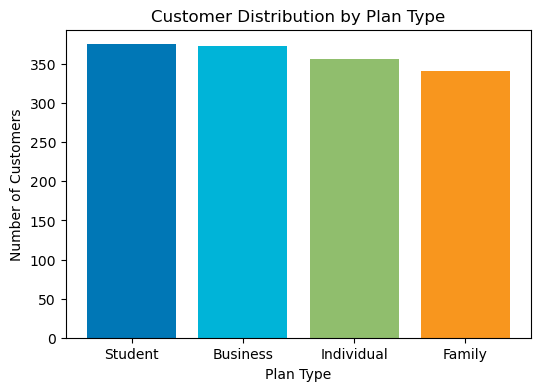

In [249]:
plan_count = df_customer_churn['plan_type'].value_counts()
colors = ['#0077B6', '#00B4D8', '#90BE6D', '#F8961E', '#F94144','#6A4C93','#577590','#43AA8B']

plt.figure(figsize=(6,4))
plt.bar(plan_count.index, plan_count.values, color = colors)
plt.title('Customer Distribution by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Number of Customers')

plt.show()

Insights
* Customer distribution is fairly balanced across all plan types.
* Business and Student plans have slightly higher customer counts.
* Family plan has the lowest number of customers among the available plans.

# Customer churn distribution

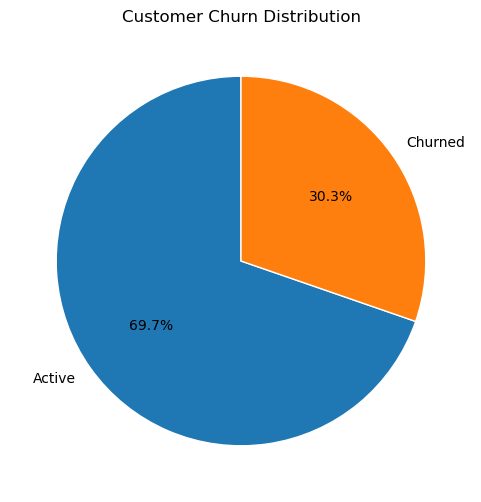

In [250]:
churn = df_customer_churn['churn_flag'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    churn,
    labels=['Active','Churned'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white'}
)
plt.title('Customer Churn Distribution')
plt.show()

Insights: 
* Around 70% of customers are active.
* Approximately 30% of customers have churned.
* Customer retention is higher than customer churn in this dataset.

# Distribution of monthly charges

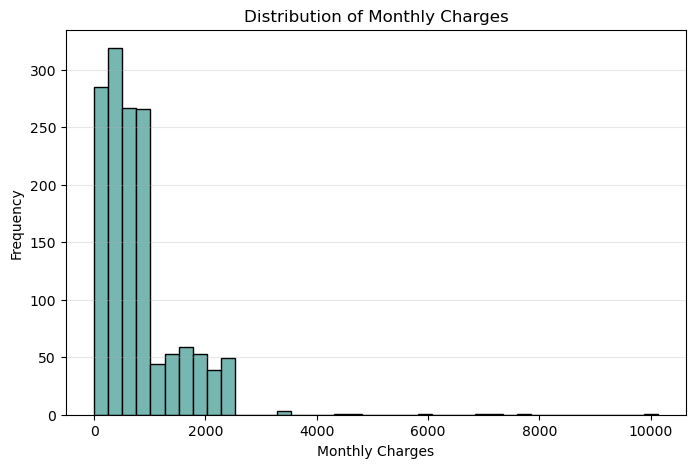

In [251]:
plt.figure(figsize=(8,5))

plt.hist(
    df_customer_churn['monthly_charges'].dropna(),
    bins=40,
    color='#76B7B2',
    edgecolor='black'
)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

Insights: 
* Monthly charges are concentrated in the lower price range.
* The distribution is right-skewed due to a few high-paying customers.
* A small number of outliers have significantly higher monthly charges.

# CLTV outlier detection

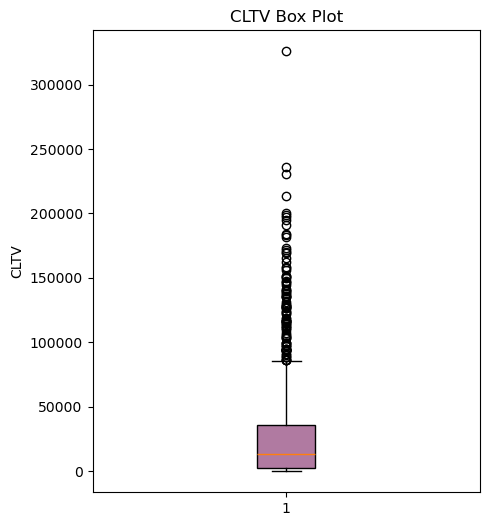

In [252]:
plt.figure(figsize=(5,6))

plt.boxplot(df_customer_churn['cltv'].dropna(),
            patch_artist=True,
            boxprops=dict(facecolor='#B07AA1'))
plt.title('CLTV Box Plot')
plt.ylabel('CLTV')
 
plt.show()

Insights: 
* Most customers have CLTV values within a lower range.
* Several high-value outliers exist, indicating a small group of highly valuable customers.
* The distribution is positively skewed due to these high-value customers.

# Correlation heatmap

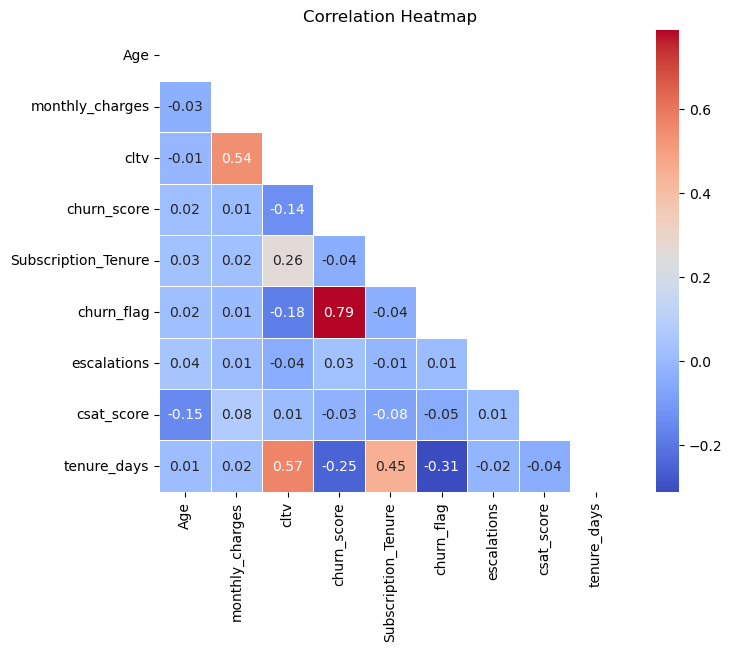

In [253]:
cols = [
    'Age',
    'monthly_charges',
    'cltv',
    'churn_score',
    'Subscription_Tenure',
    'churn_flag',
    'escalations',
    'csat_score',
    'tenure_days'
]
corr = df_customer_churn[cols].corr()

plt.figure(figsize=(9,6))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap')

plt.show()

Insights: 
* Monthly Charges and CLTV show a moderate positive correlation (0.54).
* Churn Score has a strong positive correlation with Churn Flag (0.79).
* Most other variables have weak correlations, indicating limited linear relationships.

# Yearly subscription trend

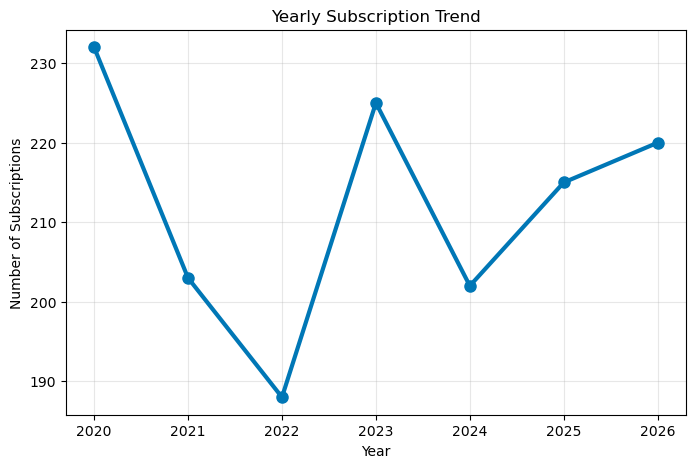

In [254]:
yearly = (df_customer_churn.groupby(df_customer_churn['subscription_start_date'].dt.to_period('Y')).size())

plt.figure(figsize=(8,5))
plt.plot(yearly.index.astype(str),
         yearly.values,
         color='#0077B6',
         linewidth=3,
         marker='o',
         markersize=8)
# plt.xticks(rotation=90)
plt.title('Yearly Subscription Trend')
plt.xlabel('Year')
plt.ylabel('Number of Subscriptions')
plt.grid(alpha=0.3)

plt.show()

Insights: 
* Customer subscriptions fluctuate across the years.
* Subscription count dropped between 2020 and 2022 before recovering in later years.
* Overall subscription volume remains relatively stable without a clear long-term upward or downward trend.

# Gender distribution

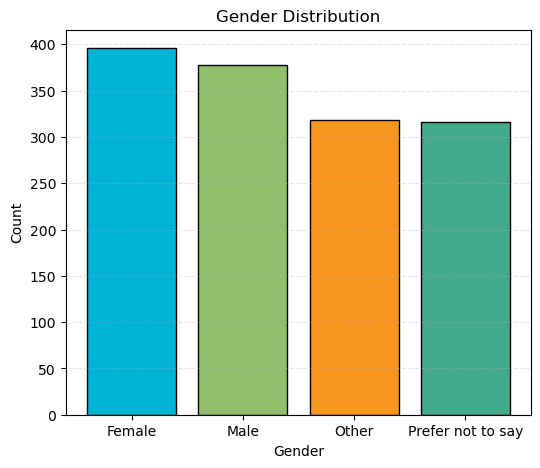

In [255]:
gender = df_customer_churn['gender'].value_counts()
colors = ['#00B4D8', '#90BE6D', '#F8961E','#43AA8B']
plt.figure(figsize=(6,5))

plt.bar(gender.index,
        gender.values,
        color= colors,
        edgecolor='black')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

Insights:
* Male and Female customers have a nearly balanced distribution.
* “Other” and “Prefer not to say” represent a smaller portion of the customer base.
* No single gender dominates the customer population.

# 8. SQL Analysis

## Create Analysis Table

Save the cleaned and merged dataset to SQLite as a new table (`customer_churn_analysis`) for SQL analysis.

In [256]:
# Save the cleaned dataset as a new SQLite table

conn = sqlite3.connect("customer_churn.db")

df_customer_churn.to_sql("customer_churn_analysis", conn, if_exists="replace", index=False)

1485

# 8.1. Top 10 Customers by CLTV

In [257]:
query = """
SELECT
    customerid,
    Customer_Name,
    cltv
FROM customer_churn_analysis
ORDER BY cltv DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,customerid,Customer_Name,cltv
0,18,Rekha Bhatia,325770.14
1,136,Manoj Reddy,236124.67
2,1355,Devendra Aggarwal,230217.21
3,183,Arjun Singhania,213313.98
4,1095,Parth Pandey,200206.52
5,616,Rohan Dubey,198864.85
6,653,harsh chatterjee,196937.35
7,500,Kailash Sethi,194615.73
8,535,Gaurav Banerjee,190793.90
9,1031,Shreya Pandey,184034.96


# 8.2. Average Monthly Charges by Plan

In [258]:
query = """
SELECT
    plan_type,
    ROUND(AVG(monthly_charges), 2) AS avg_monthly_charges
FROM customer_churn_analysis
GROUP BY plan_type
ORDER BY avg_monthly_charges DESC; 
"""

pd.read_sql(query, conn)

,plan_type,avg_monthly_charges
0,None,1001.99
1,Student,795.11
2,Business,794.38
3,Individual,748.58
4,Family,742.18


# 8.3. Churn Rate by Subscription Type

In [259]:
query = """
SELECT
    subscription_type,
    ROUND(AVG(churn_flag) * 100, 2) AS churn_rate_percent
FROM customer_churn_analysis
GROUP BY subscription_type
ORDER BY churn_rate_percent DESC;
"""

pd.read_sql(query, conn)

,subscription_type,churn_rate_percent
0,None,32.00
1,Standard,31.99
2,Premium,29.87
3,Basic,29.76
4,Free,26.78


# 8.4. Average CSAT Score

In [260]:
query = """
SELECT
    ROUND(AVG(csat_score), 2) AS average_csat_score
FROM customer_churn_analysis;
"""

pd.read_sql(query, conn)

,average_csat_score
0,3.05


# 8.5. Total Revenue by Plan

In [261]:
query = """ 
SELECT
    plan_type,
    ROUND(SUM(monthly_charges), 2) AS total_revenue
FROM customer_churn_analysis
GROUP BY plan_type
ORDER BY total_revenue DESC;
"""

pd.read_sql(query, conn)

,plan_type,total_revenue
0,Business,287567.10
1,Student,284649.70
2,Individual,263501.04
3,Family,247144.45
4,None,39077.73


## Key Business Insights

- Around **69.7%** of customers are active, while **30.3%** have churned.
- Customer distribution is balanced across all plan types, with **340–370 customers** in each plan.
- **Monthly Charges** and **CLTV** have a positive correlation of **0.54**, indicating customers paying more generally have higher lifetime value.
- **Churn Score** and **Churn Flag** have a strong positive correlation of **0.79**, making churn score a reliable churn indicator.
- A few customers have exceptionally high **CLTV (above ₹1,00,000)**, while most customers have much lower lifetime values.
- Yearly subscriptions remain fairly stable, with around **190–230 new subscriptions** each year.
- Male and Female customers are almost equally represented (**396 Female** and **378 Male**).
- Most customers pay **less than ₹1,000 per month**, while only a small number pay premium charges.
- The average **CSAT score** is **3.05/5**, indicating overall customer satisfaction.
- Data cleaning standardized missing values, corrected data types, and improved the dataset for accurate analysis.

# Conclusion

This project demonstrates a complete end-to-end customer churn analysis using SQLite, SQL, Python, Pandas, and Matplotlib.

The workflow included:
- Loading data from SQLite.
- Cleaning and transforming customer, subscription, and support datasets.
- Creating new features such as Age, Subscription Tenure, Annual Charges, and Churn Flag.
- Performing exploratory data analysis and visualization.
- Running SQL queries to answer key business questions.
- Identifying important customer behavior and churn-related insights.

The final analysis provides actionable business insights that can support customer retention strategies and improve decision-making.